### Assignment-1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
## Load the Preprocessed Dataset Here
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ImpactSense_Oct25/data/earthquakes_data.csv')
df.head()

,Unnamed: 0,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,0,1900-10-09T12:25:00.000Z,57.09,-153.48,NaN,7.86,mw,NaN,NaN,NaN,...,2022-05-09T14:44:17.838Z,"16 km SW of Old Harbor, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,pt
1,1,1901-03-03T07:45:00.000Z,36.00,-120.50,NaN,6.40,ms,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"12 km NNW of Parkfield, California",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,ell
2,2,1901-07-26T22:20:00.000Z,40.80,-115.70,NaN,5.00,fa,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"6 km SE of Elko, Nevada",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,sjg
3,3,1901-12-30T22:34:00.000Z,52.00,-160.00,NaN,7.00,ms,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,south of Alaska,earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,abe
4,4,1902-01-01T05:20:30.000Z,52.38,-167.45,NaN,7.00,ms,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"113 km ESE of Nikolski, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,abe


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110133 entries, 0 to 110132
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       110133 non-null  int64  
 1   time             110133 non-null  object 
 2   latitude         110133 non-null  float64
 3   longitude        110133 non-null  float64
 4   depth            109848 non-null  float64
 5   mag              110133 non-null  float64
 6   magType          110133 non-null  object 
 7   nst              39492 non-null   float64
 8   gap              49783 non-null   float64
 9   dmin             29839 non-null   float64
 10  rms              81386 non-null   float64
 11  net              110133 non-null  object 
 12  id               110133 non-null  object 
 13  updated          110133 non-null  object 
 14  place            109242 non-null  object 
 15  type             110133 non-null  object 
 16  horizontalError  28459 non-null   floa

In [7]:
df.describe()

,Unnamed: 0,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,110133.000000,110133.000000,110133.000000,109848.000000,110133.000000,39492.000000,49783.000000,29839.000000,81386.000000,28459.000000,60418.000000,43072.000000,50108.000000
mean,55066.000000,3.692374,41.402767,61.340488,5.441380,141.146283,65.583967,4.199523,0.947658,7.864240,7.282601,0.148807,64.465774
std,31792.802936,30.432835,121.960837,107.639693,0.479188,117.023302,39.212698,5.191667,0.365004,3.912147,10.139548,0.145688,101.396169
min,0.000000,-77.080000,-179.997000,-4.000000,5.000000,0.000000,6.500000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000
25%,27533.000000,-17.855000,-72.002000,10.000000,5.100000,63.000000,37.000000,1.296000,0.800000,6.200000,1.900000,0.055000,13.000000
50%,55066.000000,-0.696000,100.391000,33.000000,5.300000,103.000000,57.000000,2.514000,0.950000,7.750000,4.600000,0.081000,30.000000
75%,82599.000000,29.883500,143.175000,51.000000,5.630000,179.000000,84.400000,4.915000,1.100000,9.375000,8.200000,0.200000,68.000000
max,110132.000000,87.386000,180.000000,700.000000,9.500000,929.000000,360.000000,50.901000,69.320000,99.000000,1091.900000,1.840000,1144.000000


Q1. Analyze the distribution of earthquake magnitudes (mag) and explore how they vary across different earthquake types (type) using visualizations such as boxplots or violin plots.

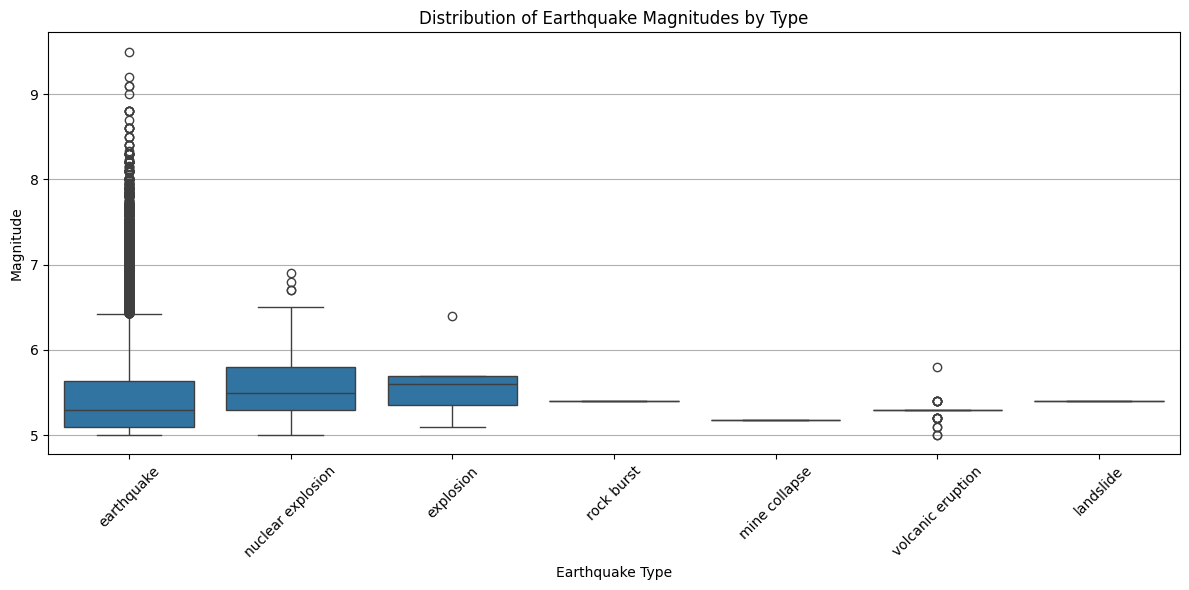

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='mag', data=df)
plt.title('Distribution of Earthquake Magnitudes by Type')
plt.xlabel('Earthquake Type')
plt.ylabel('Magnitude')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Q2. Explore the relationship between earthquake depth (depth) and magnitude (mag). Is there a trend or correlation between these two features in the dataset?

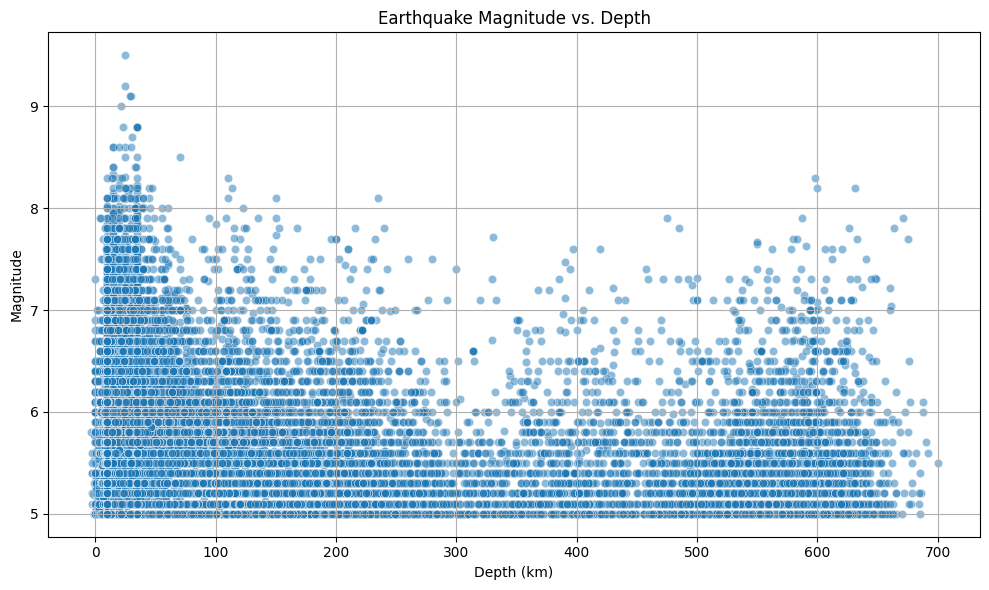

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='depth', y='mag', data=df, alpha=0.5)
plt.title('Earthquake Magnitude vs. Depth')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

Q3. Using the preprocessed temporal features (Year, Month, Day, Hour), investigate if there is any difference in earthquake frequency or magnitude over months or years. Visualize temporal trends clearly.

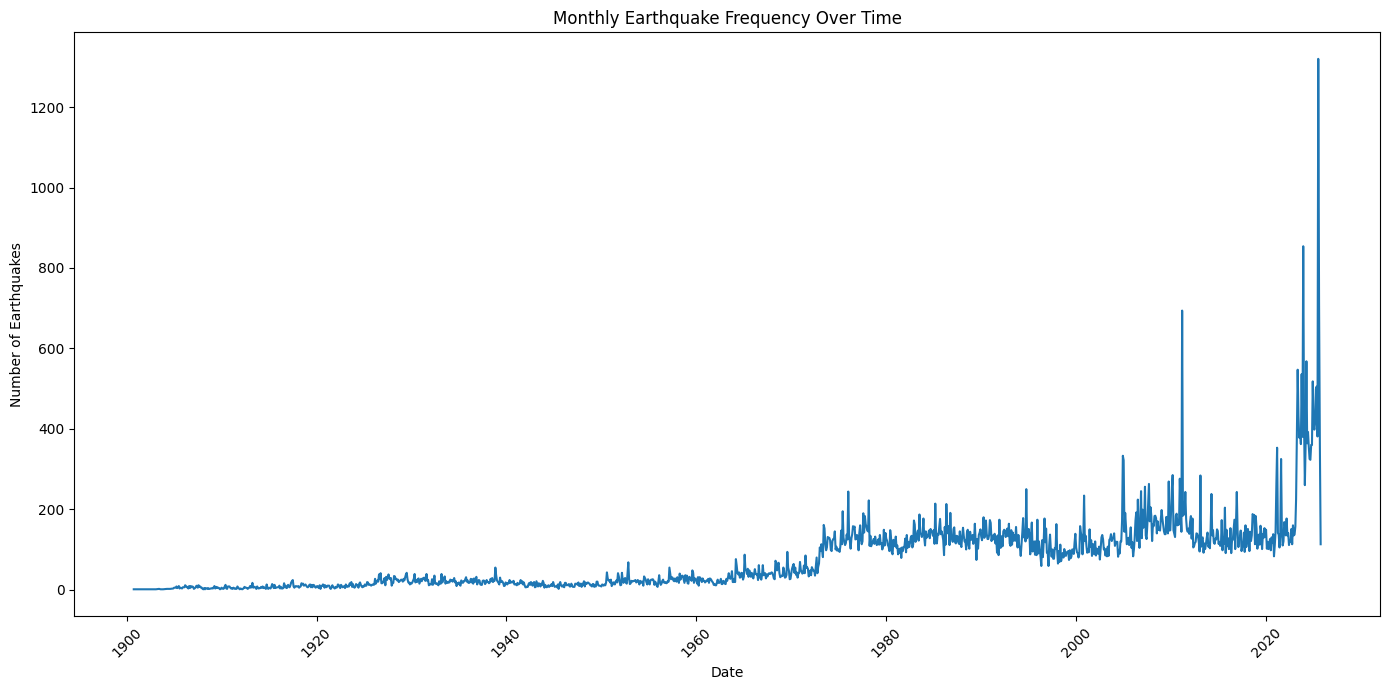

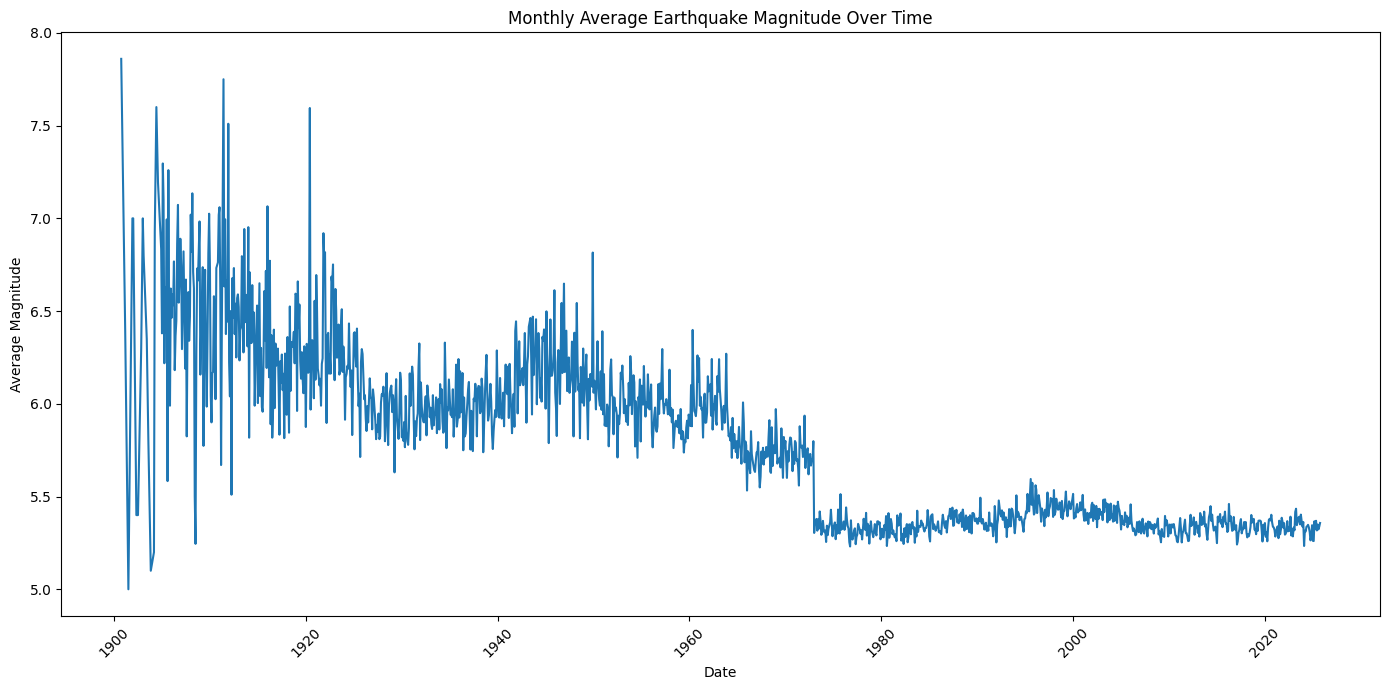

In [10]:
df['time'] = pd.to_datetime(df['time'])
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month

earthquake_counts = df.groupby(['Year', 'Month']).size().reset_index(name='count')
earthquake_counts['Date'] = pd.to_datetime(earthquake_counts['Year'].astype(str) + '-' + earthquake_counts['Month'].astype(str))

earthquake_magnitude_avg = df.groupby(['Year', 'Month'])['mag'].mean().reset_index(name='average_magnitude')
earthquake_magnitude_avg['Date'] = pd.to_datetime(earthquake_magnitude_avg['Year'].astype(str) + '-' + earthquake_magnitude_avg['Month'].astype(str))

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='count', data=earthquake_counts)
plt.title('Monthly Earthquake Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='average_magnitude', data=earthquake_magnitude_avg)
plt.title('Monthly Average Earthquake Magnitude Over Time')
plt.xlabel('Date')
plt.ylabel('Average Magnitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Q4. Identify the most active geographical earthquake regions by plotting earthquake locations (latitude and longitude) on a map with color coding or size scaled by earthquake magnitude.

In [12]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 70.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


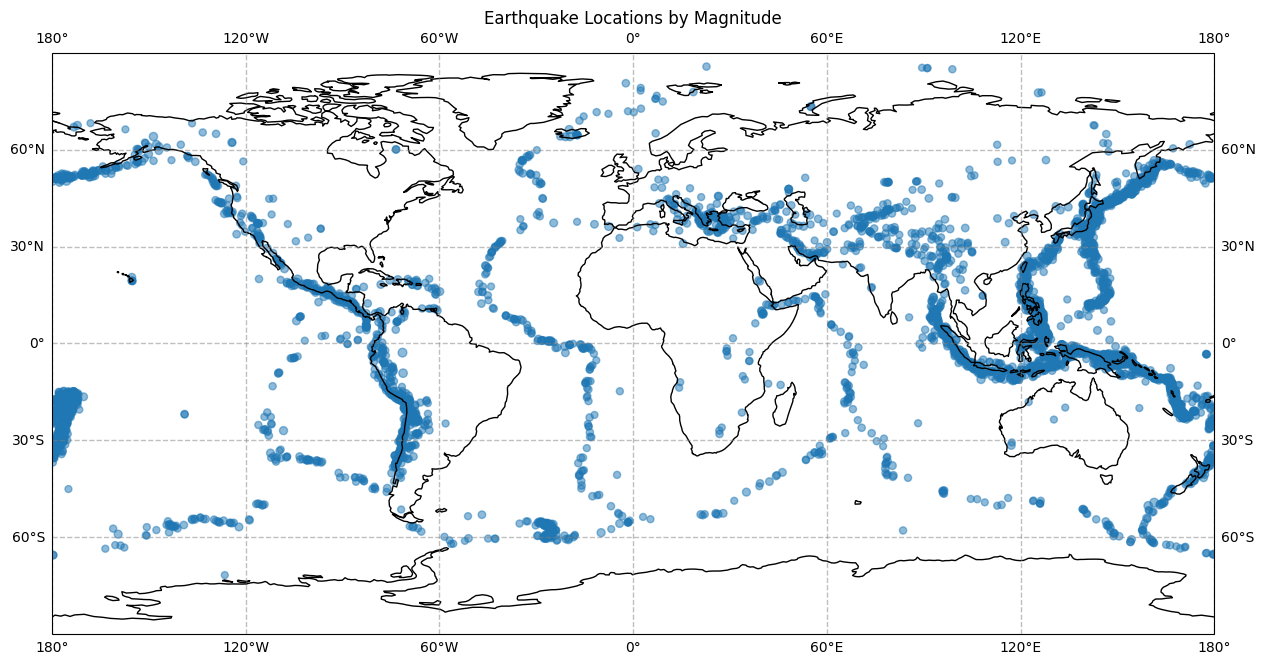

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Create a figure and axes with a PlateCarree projection
plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_global()

# Plot the earthquakes, scaling marker size by magnitude
# We'll use a small subset of the data for faster plotting
subset_df = df.sample(n=5000, random_state=42) # Adjust n for more/fewer points

ax.scatter(subset_df['longitude'], subset_df['latitude'], s=subset_df['mag']*5, alpha=0.5,
           transform=ccrs.Geodetic(), label='Earthquakes')

# Add gridlines
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')

# Add a title
plt.title('Earthquake Locations by Magnitude')

# Show the plot
plt.show()